# Phage genome analysis

In order to look for enrichment of certain nucleotides in the spacer seqeucens we need to work out the baseline properties of the phage genome, then we can look at the relative differences between the spacer seqeucnes  that are integrated into the CRISPR array veruses the rest of the phage genomes that did not get intgrated.<br>

Perform blast search of all the spacer sequences in the preliminary analysis and see what have a hit in the NCBI database.<br>

First try to blast the spacer sequences against the core_nt database, which is a reduced version of NCBI nt database.

In [1]:
import sys, os
import pandas as pd
import numpy as np
import json
import subprocess
from pathlib import Path
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO
import modules.analysis_utils as analysis_utils
import modules.database_utils as db_utils
from concurrent.futures import ProcessPoolExecutor
import modules.blast_utils as blast_utils
from modules.blast_utils import PhageBlast
from IPython.display import display
from plotnine import (ggplot, aes, geom_histogram, geom_density, theme_bw, 
                      labs, theme, element_text, scale_x_continuous, geom_vline, 
                      geom_boxplot, geom_jitter, scale_x_discrete, stat_summary,
                      scale_y_continuous)
import matplotlib.pyplot as plt
from modules.analysis_utils import PhageElement
import logomaker

In [2]:
def subprocess_run(cmd):
    """
    Run a subprocess command and check for errors.
    """
    try:
        print(f"Running command: {' '.join(cmd)}")
        subprocess.run(cmd, check=True)
    except subprocess.CalledProcessError as e:
        print(f"Error during command execution: {e}")
        sys.exit(1)

In [2]:
core_nt_path = '/core_nt/'

core_nt_json = json.load(open(f"{core_nt_path}/core_nt-nucl-metadata.json"))
files_url = core_nt_json["files"]
for url in files_url:
    # Download the file and extract it
    wget_cmd = ["wget", "-P", core_nt_path, url]
    subprocess_run(wget_cmd)
    file_path = os.path.join(core_nt_path, os.path.basename(url))
    tar_cmd = ["tar", "-xvzf", file_path, "-C", core_nt_path]
    subprocess_run(tar_cmd)
    # Remove the tar file after extraction
    rm_cmd = ["rm", file_path]
    subprocess_run(rm_cmd)

FileNotFoundError: [Errno 2] No such file or directory: '/core_nt//core_nt-nucl-metadata.json'

Blast spacer sequences against core nt database

In [ ]:
array_df = db_utils.read_table_from_db("prelim/analysis/preliminary_crisprs.csv")
spacer_df = db_utils.read_table_from_db("prelim/analysis/all_spacers.csv")
output_dir = Path(f"/spacers_db/blastn_results/")

array_filt = array_df.drop_duplicates(subset=['array_id'])
array_filt = array_filt[
    (array_filt['category'] != 'Alternative') &
    (array_filt['spacer_len_var'] < 1) &
    (array_filt['filter'] == 'PASSED')
]

filt_seqs = spacer_df[spacer_df['array_id'].isin(array_filt['array_id'])]

seq_with_species = filt_seqs.merge(
    array_df[['array_id', 'speciesname', 'biosampleaccn']],
    on='array_id',
    how='left'        
)

filt_seqs = spacer_df[spacer_df['array_id'].isin(array_filt['array_id'])]

row_data_list = [(row, output_dir) for _, row in seq_with_species.iterrows()]

blast_db = Path('/spacers_db/phagescope/phagescope_db')

# Run blastn in parallel
with ProcessPoolExecutor(max_workers=4) as executor:
    executor.map(blast_utils.process_sequence, [blast_db]*len(row_data_list), row_data_list)

In [ ]:
home_dir = Path('/home/unimelb.edu.au/rbengtsson/work/spacer_analysis/')

df = pd.DataFrame(columns=[
    'sequence_id', 'spacerhost', 'phage_id', 'pidenty', 'algn_length',
    'mismatch', 'phagestart', 'phageend', 'phagelength','evalue', 'bitscore',
    'phagecg', 'phagetaxonomy', 'phagecompleteness', 'phagehost',
    'phagelifestyle', 'phagesource'
])

for index, row in seq_with_species.iterrows():
    sequence_id = row['sequence_id']
    speciesname = row['speciesname']
    blast_file = output_dir / f"{sequence_id}_blast_results.txt"
    if not blast_file.exists():
        pass
    else:
        for line in open(blast_file, 'r'):
            phage_instance = PhageBlast.from_blast_line(line)
            phage_instance.spacerhost = speciesname
            new_df = pd.DataFrame([phage_instance.__dict__])
            df = pd.concat([df, new_df], ignore_index=True)

df.to_csv(f"{home_dir}/phage/spacer_phageblastn_results.csv")

In [2]:
blastn_df = db_utils.read_table_from_db("/spacers_db/blastn_results/spacer_phageblastn_results_85identity_95cov_01-08-2025-16-46-20.csv")

blastn_filt = blastn_df[blastn_df['completeness'].isin(['Complete', 'High-quality'])]

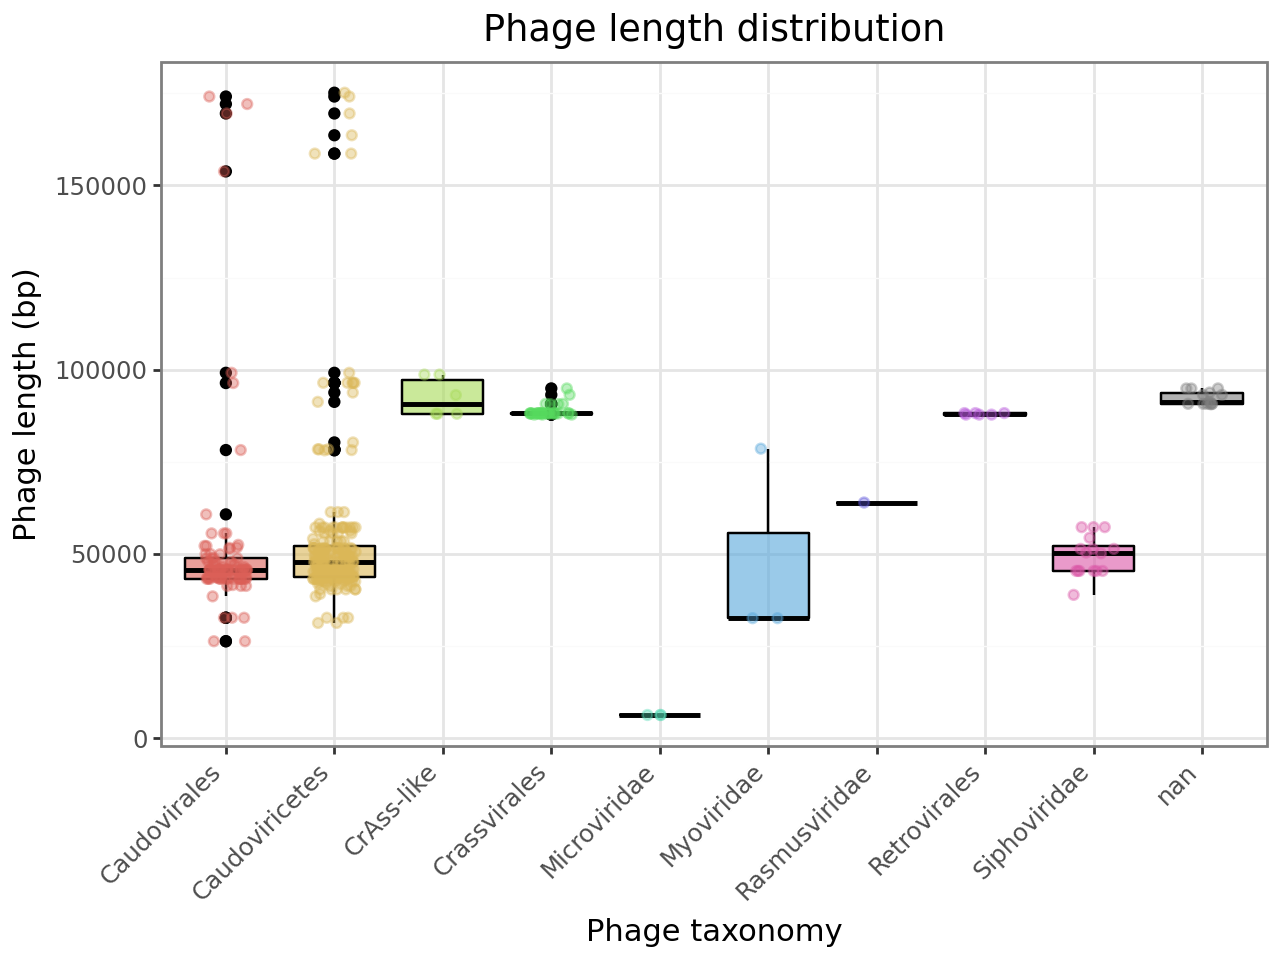

In [4]:
p_box = (
    # ggplot(blastn_filt[blastn_filt['spacerhost'] == 'Prevotella pectinovora'], aes(x='phagetaxonomy', y='phagelength', fill='phagetaxonomy')) +
    ggplot(blastn_filt, aes(x='phagetaxonomy', y='phagelength', fill='phagetaxonomy')) +
    geom_boxplot(alpha=0.6, color="black") +
    geom_jitter(aes(color='phagetaxonomy'), alpha=0.4, width=0.2) +
    # scale_x_discrete(limits=blastn_filt['category'].unique()) +
    # scale_y_continuous(breaks=list(range(0, int(blastn_filt['avgspacerlen'].max()) + 5, 5))) +
    theme_bw() +
    labs(
        title='Phage length distribution',
        x='Phage taxonomy',
        y='Phage length (bp)'
    ) +
    theme(axis_text_x=element_text(rotation=45, hjust=1), legend_position='none')    
)

display(p_box)

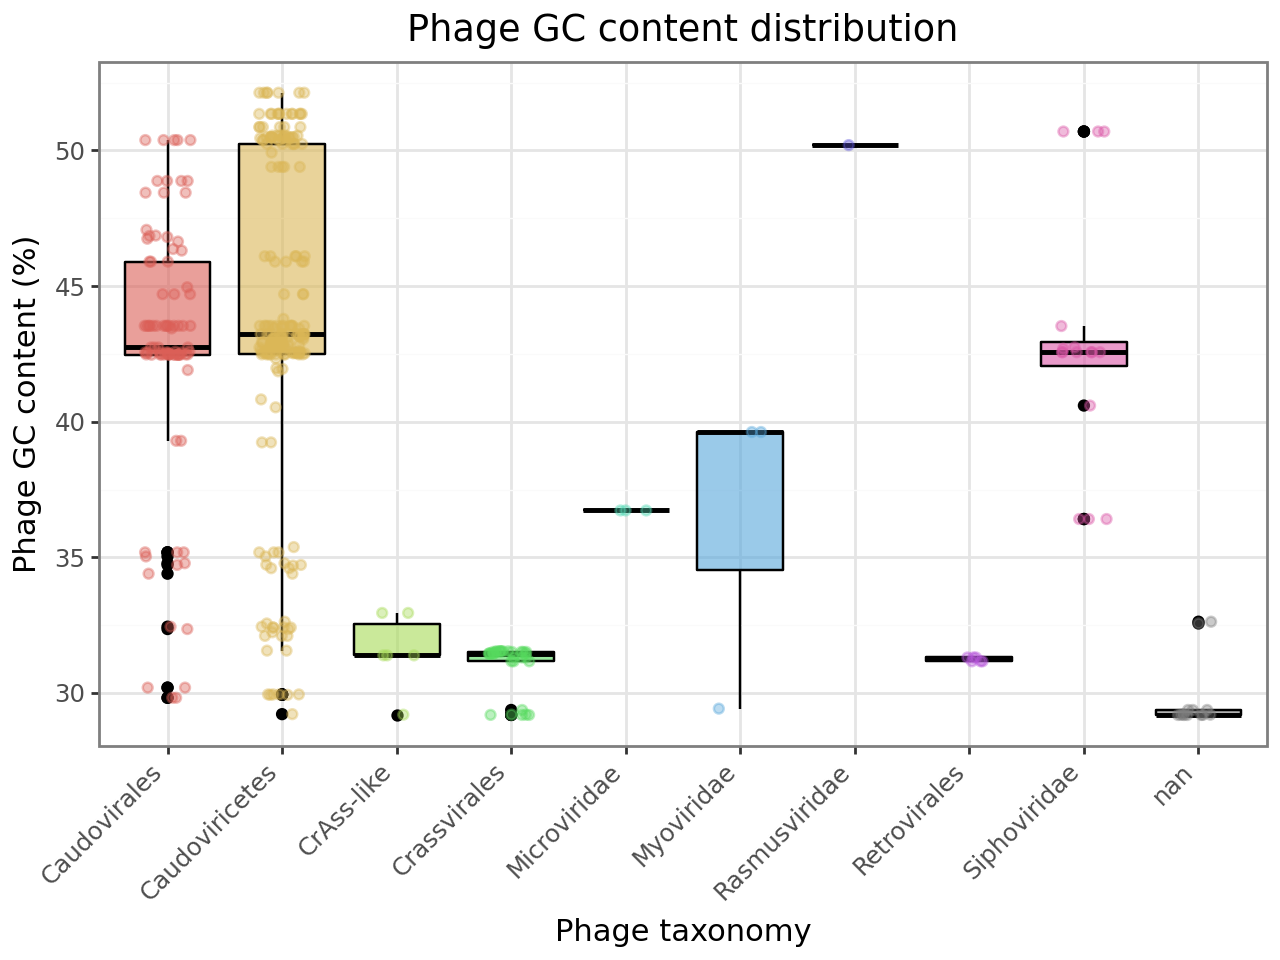

In [5]:
p_box = (
    # ggplot(blastn_filt[blastn_filt['spacerhost'] == 'Prevotella pectinovora'], aes(x='phagetaxonomy', y='phagecg', fill='phagetaxonomy')) +
    ggplot(blastn_filt, aes(x='phagetaxonomy', y='phagecg', fill='phagetaxonomy')) +
    geom_boxplot(alpha=0.6, color="black") +
    geom_jitter(aes(color='phagetaxonomy'), alpha=0.4, width=0.2) +
    # scale_x_discrete(limits=blastn_filt['category'].unique()) +
    # scale_y_continuous(breaks=list(range(0, int(blastn_filt['avgspacerlen'].max()) + 5, 5))) +
    theme_bw() +
    labs(
        title='Phage GC content distribution',
        x='Phage taxonomy',
        y='Phage GC content (%)'
    ) +
    theme(axis_text_x=element_text(rotation=45, hjust=1), legend_position='none')    
)

display(p_box)

In [3]:
def calculate_relative_position(d, phage_length):
    """
    Calculate the relative position of a spacer within a phage genome.
    """

    d['relative_position'] = (d['phagestart'] + d['phageend']) / (2 * phage_length)
    return d

blastn_positions = calculate_relative_position(blastn_filt, blastn_filt['phagelength'])


/tmp/ipykernel_1423700/1540649536.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


/tmp/ipykernel_1414102/4285287229.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/home/unimelb.edu.au/rbengtsson/miniconda3/envs/modules/lib/python3.10/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_histogram : Removed 2 rows containing missing values.


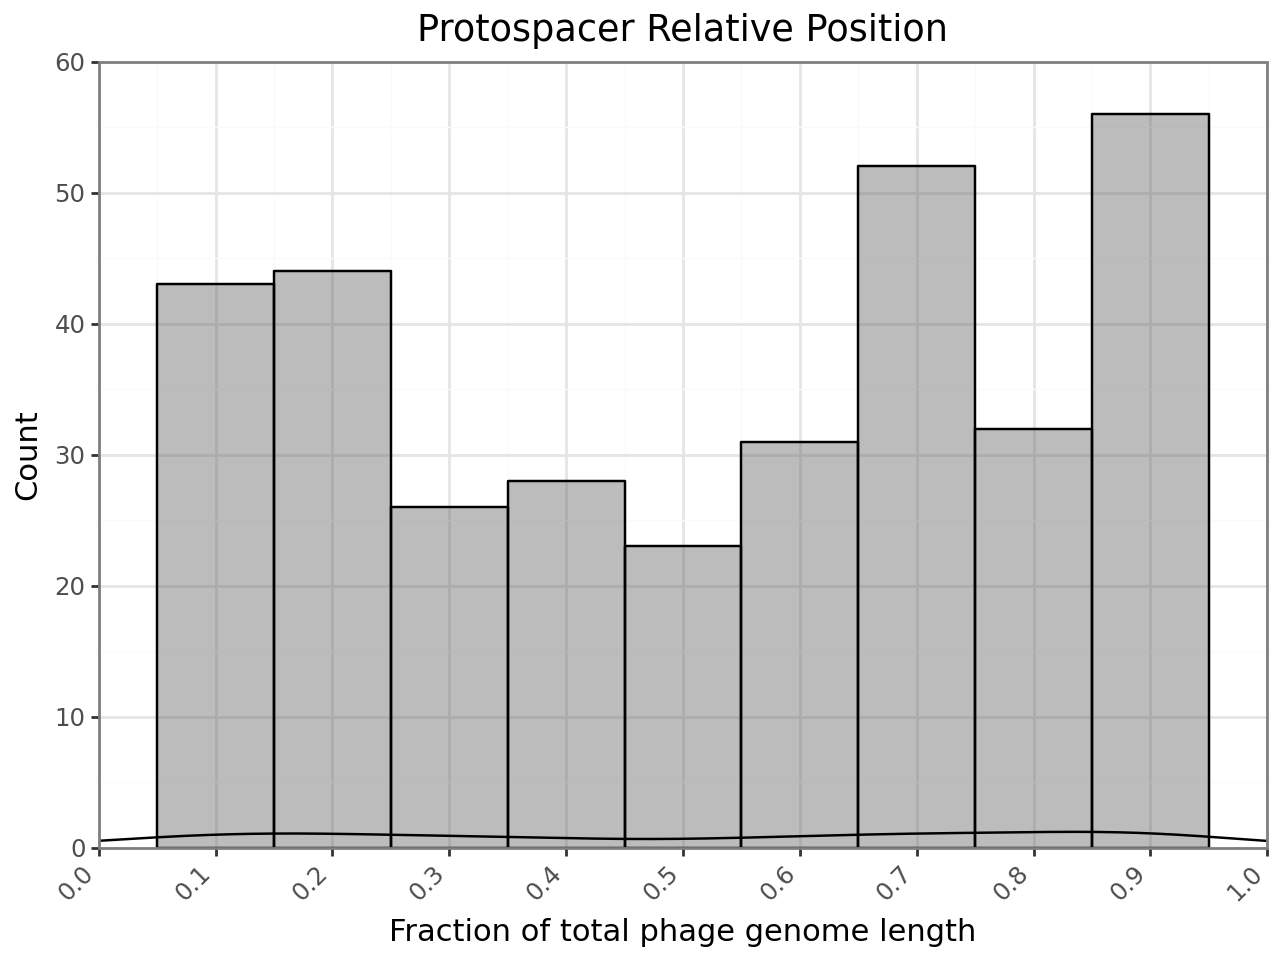

In [ ]:
p_freq = (
    # ggplot(blastn_positions[blastn_positions['spacerhost'] == 'Porphyromonas gingivalis'], aes(x='relative_position')) +
    ggplot(blastn_positions, aes(x='relative_position')) +
    geom_histogram(binwidth=0.1, position="identity", alpha=0.4, color="black") +
    geom_density(alpha=0.6) +
    scale_y_continuous(limits=(0, 60), expand=(0, 0)) +
    scale_x_continuous(expand=(0, 0), limits=(0, 1), breaks=np.arange(0, 1.1, 0.1)) +
    theme_bw() +
    labs(title='Protospacer Relative Position',
        x='Fraction of total phage genome length',
        y='Count') +
    theme(axis_text_x=element_text(rotation=45, hjust=1))
    )


display(p_freq)

/home/unimelb.edu.au/rbengtsson/miniconda3/envs/modules/lib/python3.10/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_histogram : Removed 2 rows containing missing values.


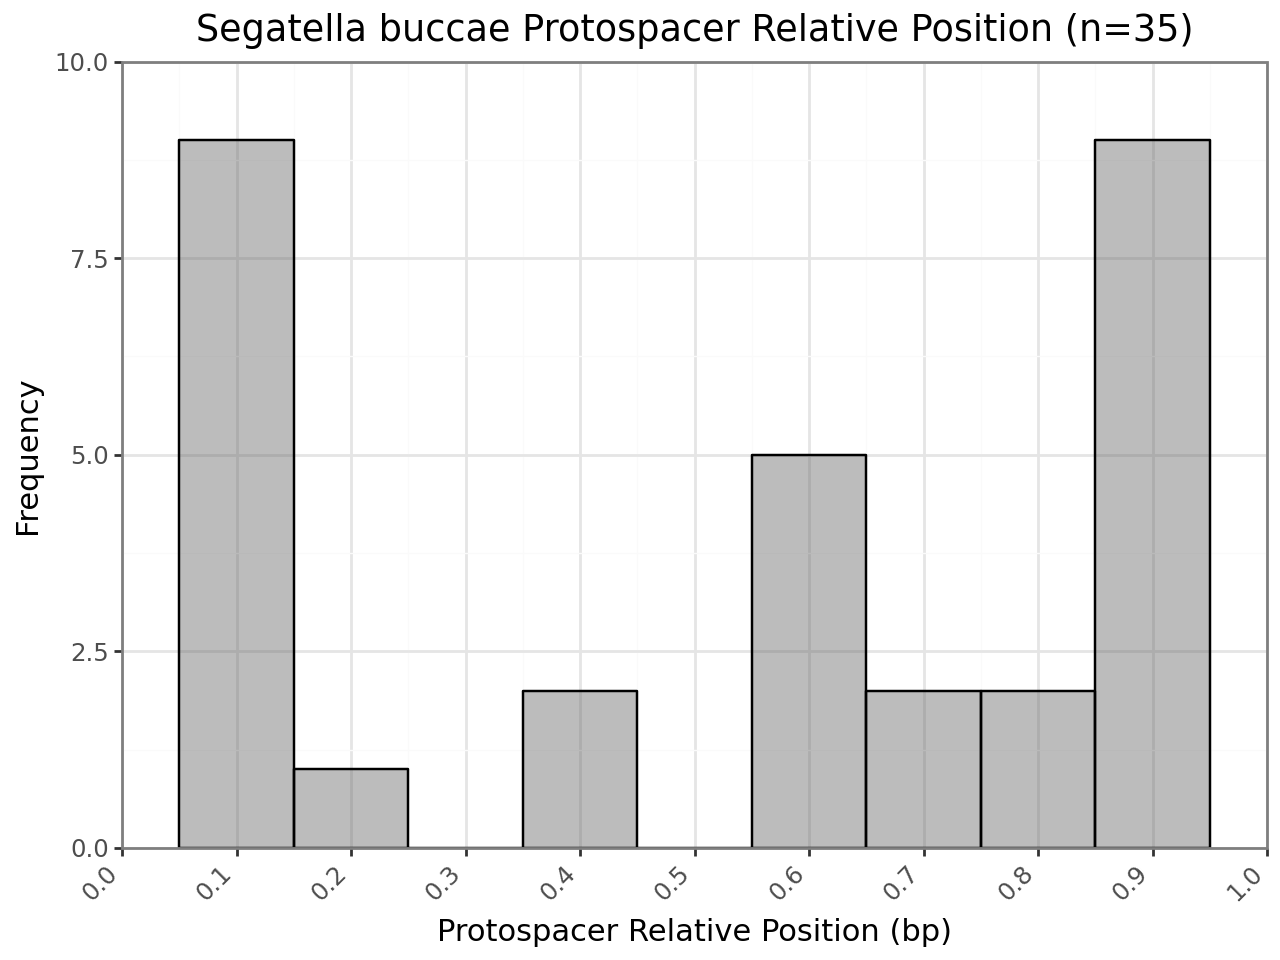

In [ ]:
species = 'Segatella buccae'
n = len(blastn_positions[blastn_positions['spacerhost'] == species])
binwidth = 0.1

p_freq = (
    ggplot(blastn_positions[blastn_positions['spacerhost'] == species], aes(x='relative_position')) +
    # ggplot(blastn_positions, aes(x='relative_position')) +
    geom_histogram(binwidth=binwidth, position="identity", alpha=0.4, color="black") +
    # geom_density(alpha=0.6) +
    scale_y_continuous(limits=(0, 10), expand=(0, 0)) +
    scale_x_continuous(expand=(0, 0), limits=(0, 1), breaks=np.arange(0, 1.1, 0.1)) +
    theme_bw() +
    labs(title=f'{species} Protospacer Relative Position (n={n})',
        x='Fraction of total phage genome length',
        y='Frequency') +
    theme(axis_text_x=element_text(rotation=45, hjust=1))
    )


display(p_freq)

/home/unimelb.edu.au/rbengtsson/miniconda3/envs/modules/lib/python3.10/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_histogram : Removed 2 rows containing missing values.


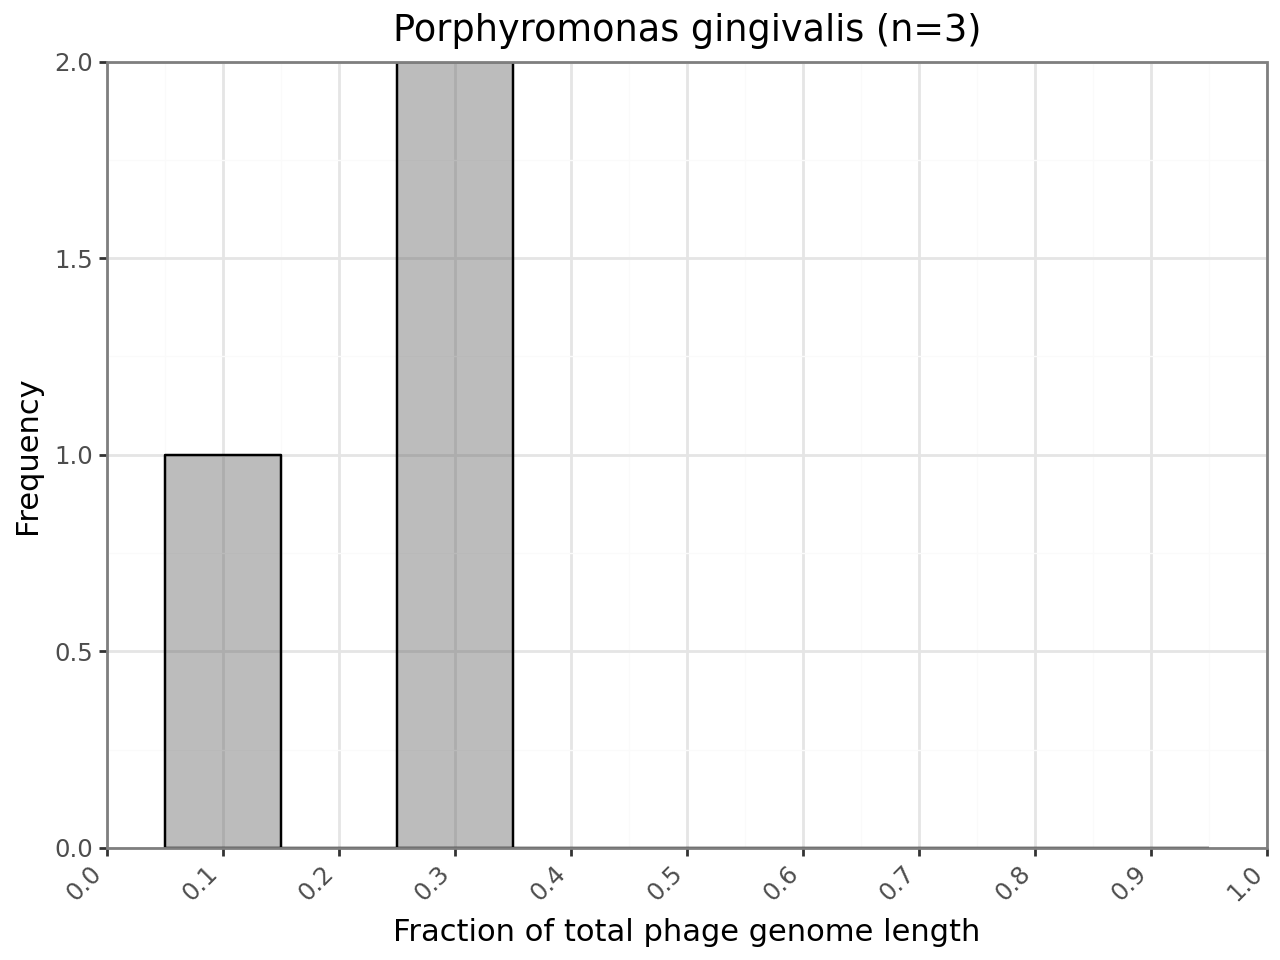

In [ ]:
# separate by bacteriophage taxonomy
species = 'Porphyromonas gingivalis'
phage = 'Caudoviricetes'

n = len(blastn_positions[(blastn_positions['phagehost'] == species) & (blastn_positions['phagetaxonomy'] == phage)])
binwidth = 0.1

p_freq = (
    ggplot(blastn_positions[(blastn_positions['phagehost'] == species) & (blastn_positions['phagetaxonomy'] == phage)], aes(x='relative_position')) +
    # ggplot(blastn_positions, aes(x='relative_position')) +
    geom_histogram(binwidth=binwidth, position="identity", alpha=0.4, color="black") +
    # geom_density(alpha=0.6) +
    scale_y_continuous(limits=(0, None), expand=(0, 0)) +
    scale_x_continuous(expand=(0, 0), limits=(0, 1), breaks=np.arange(0, 1.1, 0.1)) +
    theme_bw() +
    labs(title=f'{species} (n={n})',
        x='Fraction of total phage genome length',
        y='Frequency') +
    theme(axis_text_x=element_text(rotation=45, hjust=1))
    )


display(p_freq)


Extract all ORF in the phage genome that overlap with the corresponding protospacer. 

In [ ]:
home_dir = Path('/home/unimelb.edu.au/rbengtsson/work/spacer_analysis/')
blastn_file = f"{home_dir}/phage/spacer_phageblastn_results.csv"

blastn_df = db_utils.read_table_from_db(blastn_file)
sequence_id_list = blastn_df['sequence_id'].unique().tolist()

out_dir = Path(f"/spacers_db/blastn_results/")
    
# run intersection in parallel
with ProcessPoolExecutor(max_workers=4) as executor:
    executor.map(PhageElement.get_intersection, sequence_id_list, [blastn_file]*len(sequence_id_list), [out_dir]*len(sequence_id_list))

In the paper by [Hoikkala et al](https://journals.asm.org/doi/epdf/10.1128/mbio.03338-20), they mapped the spacer sequence from Flavobacterium columnare (CFB group bacteria) (SAMN03382583) onto the phage FCL-2 (accession no. [NC_027125.1](https://www.ncbi.nlm.nih.gov/nuccore/NC_027125.1)) genome to identify where the protospacers from the CRISPR array originated. The authors observed that 4 of the spacers originated from the distal end of the phage.<br>

Will run this through the pipeline and see if we observe the same location of the 4 protospacers.

In [ ]:
psql -U rjbengtsson -d cas13_bacterial_db -c "\COPY (
  SELECT c.*, n.organism, n.speciesname
  FROM cas13b_crisprs AS c
  JOIN ncbi_assembly AS n ON c.biosampleaccn = n.biosampleaccn
  WHERE c.biosampleaccn = 'SAMN03382583'
) TO 'prelim/analysis/SAMN03382583_crisprs.csv' CSV HEADER"

In [ ]:
psql -U rjbengtsson -d cas13_bacterial_db -c "\COPY (
  SELECT *
  FROM spacer_table
  WHERE array_id = '204ac2c3-7842-4f97-b299-8b3cb14d68d7'
) TO 'prelim/analysis/SAMN03382583_spacers.csv' CSV HEADER"

In [ ]:
array_df = db_utils.read_table_from_db("prelim/analysis/SAMN03382583_crisprs.csv")
spacer_df = db_utils.read_table_from_db("prelim/analysis/SAMN03382583_spacers.csv")
output_dir = Path(f"/spacers_db/blastn_results/")

array_filt = array_df.drop_duplicates(subset=['array_id'])
array_filt = array_filt[
    (array_filt['category'] != 'Alternative') &
    (array_filt['spacer_len_var'] < 1) &
    (array_filt['filter'] == 'PASSED')
]

filt_seqs = spacer_df[spacer_df['array_id'].isin(array_filt['array_id'])]

seq_with_species = filt_seqs.merge(
    array_df[['array_id', 'speciesname', 'biosampleaccn']],
    on='array_id',
    how='left'        
)

seq_with_species_spacers = seq_with_species[seq_with_species['type'] == 'spacer']

row_data_list = [(row, output_dir) for _, row in seq_with_species_spacers.iterrows()]

blast_db = Path('/spacers_db/phagescope/phagescope_db')

# Run blastn in parallel
with ProcessPoolExecutor(max_workers=4) as executor:
    executor.map(blast_utils.process_sequence, [blast_db]*len(row_data_list), row_data_list)

In [ ]:
home_dir = Path('/home/unimelb.edu.au/rbengtsson/work/spacer_analysis/')

df = pd.DataFrame(columns=[
    'sequence_id', 'spacerhost', 'phage_id', 'pidenty', 'algn_length',
    'mismatch', 'phagestart', 'phageend', 'phagelength','evalue', 'bitscore',
    'phagecg', 'phagetaxonomy', 'phagecompleteness', 'phagehost',
    'phagelifestyle', 'phagesource'
])

for index, row in seq_with_species_spacers.iterrows():
    sequence_id = row['sequence_id']
    speciesname = row['speciesname']
    blast_file = output_dir / f"{sequence_id}_blast_results.txt"
    if not blast_file.exists():
        pass
    else:
        for line in open(blast_file, 'r'):
            phage_instance = PhageBlast.from_blast_line(line)
            phage_instance.spacerhost = speciesname
            new_df = pd.DataFrame([phage_instance.__dict__])
            df = pd.concat([df, new_df], ignore_index=True)

df.to_csv(f"{home_dir}/phage/SAMN03382583_spacer_phageblastn_results.csv")

Blasting the spacer sequences of Cas13b CRISPR array from sample SAMN03382583 against the PhageScope database only returned one hit for one spacer sequence (395f8549-8b33-4ca3-aafd-32022bc5c845). The matching phage accession is NC_041845.1 which is not the FCL-2 phage (Flavobacterium phage FCL-2: NC_027125.1) used in the experiement from the paper.

In [14]:
def calculate_relative_position(d, phage_length):
    """
    Calculate the relative position of a spacer within a phage genome.
    """

    d['relative_position'] = (d['phagestart'] + d['phageend']) / (2 * phage_length)
    return d

blastn_df = db_utils.read_table_from_db("phage/SAMN03382583_spacer_phageblastn_results.csv")
blastn_filt = blastn_df[blastn_df['completeness'].isin(['Complete', 'High-quality'])]
blastn_positions = calculate_relative_position(blastn_filt, blastn_filt['phagelength'])
print(blastn_positions)



   Unnamed: 0                           sequence_id                spacerhost  \
0           0  395f8549-8b33-4ca3-aafd-32022bc5c845  Flavobacterium columnare   

      phage_id  pidenty  algn_length  mismatch  phagestart  phageend  \
0  NC_041845.1      NaN           29         0       42979     42951   

   phagelength  ...    phagecg  phagetaxonomy  phagecompleteness  \
0        46450  ...  29.823466   Caudovirales                NaN   

                  phagehost  phagelifestyle phagesource  pident  completeness  \
0  Flavobacterium columnare             NaN      REFSEQ   100.0  High-quality   

   lifestyle relative_position  
0   virulent          0.924973  

[1 rows x 22 columns]


## Protospacer motif

In [ ]:
blastn_file = f"/spacers_db/blastn_results/spacer_phageblastn_results_85identity_95cov_01-08-2025-16-46-20.csv"
blastn_df = db_utils.read_table_from_db(blastn_file)

phage_ids = blastn_df[blastn_df['spacerhost'] == species]['phage_id'].unique().tolist()

fasta_file = f"/phagescope_db/phagescope/phagescope_combined.fasta"
outfile = "phage/test_env/phage_genomes.fasta"

with ProcessPoolExecutor(max_workers=4) as executor:
    record_list = list(executor.map(
        analysis_utils.get_genome_seq_from_fasta, [fasta_file]*len(phage_ids), phage_ids
    ))

with open(f"{outfile}", "w") as output_handle:
    SeqIO.write(record_list, output_handle, "fasta")


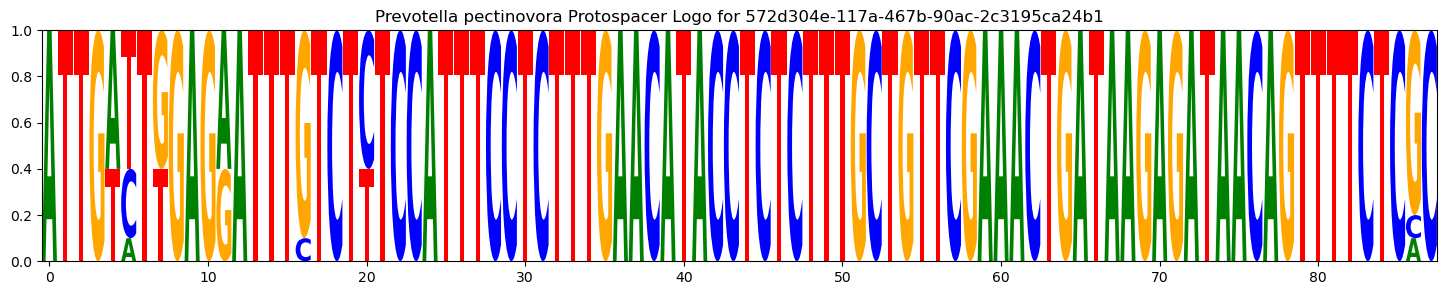

In [ ]:
phage_genome = f"/phagescope_db/phagescope/phagescope_combined.fasta"

species = 'Prevotella pectinovora'
sequence_id = '3e0a0dcc-b18c-43f8-a8c3-f8d31acba2a9'

df = blastn_df[(blastn_df['spacerhost'] == species) & (blastn_df['sequence_id'] == sequence_id)]

seq_list = []

for index, row in df.iterrows():
    phage_id = row['phage_id']
    for record in SeqIO.parse(phage_genome, "fasta"):
        if record.id == phage_id:
            start = int(row['phagestart']) + 1
            end = int(row['phageend'])
            record_seq = str(record.seq[start-30:end+30])
            seq_list.append(record_seq)

counts_matrix = logomaker.alignment_to_matrix(sequences=seq_list)
prob_matrix = logomaker.transform_matrix(counts_matrix, from_type='counts', to_type='probability', pseudocount=0)
fig, ax = plt.subplots(figsize=(18, 3))
logo = logomaker.Logo(prob_matrix, ax=ax)

plt.title(f"{species} Protospacer Logo for {sequence_id}")
plt.show()